## <center>Test technique : Prédiction du vainqueur d'un match de tennis - Siwar ABBES</center> 
------------------------------------------------------------------------------------------------------------------


1. [Importation des librairies](#Importation)
2. [Exploration des données](#EDA)
3. [Feature Engineering](#engineering)
4. [Entrainement des modèles](#train)
5. [Prédiction et analyse des résultats](#predict)

#### Le but est de réaliser un modèle prédisant le vainqueur d’un match de tennis et d’en tirer de la valeur exploitable par un client.

Le livrable est un dossier contenant : 

- des scripts python exécutables et exécutés
- Un README.md présentant les instructions pour exécuter le code et les résultats dans les grandes lignes
- Un dossier avec des output (images et visualisations)
- Tout autre fichier qui permet d’exécuter le code et montrer les résultats

On souhaite avoir :

- Une exploration des données
- L'entra√Ænement de modèlesde prédiction
- Une analyse des performances
- Une présentation d'un cas d'utilisation
- Des pistes pour poursuivre le PoC
- Des script permettant la mise en production du code
chacune de ces parties fait l'objet d'une section dans le README.md

Conditions de passation :

A la maison
Cet exercice doit être réalisé en 4h maximum
Dans des conditions normales de travail (accès à internet, etc.)
Critères d'évaluation :

- Qualité de la méthode data science (la performance du modèle n’est pas le critère d’évaluation principal de l’exercice) ;
- Qualité de la compréhension du problème client, des données et des solutions envisagées
- Qualité de présentation des résultats
- Qualité du code: structuration, modularité, documentation
Important :

Merci de noter votre NOM Prénom sur le nom de fichier que vous nous transmettez.
Merci également de ne pas diffuser vos résultats publiquement (kaggle, github, gitlab, …). »

<a id='Importation'></a>
### 1. Importation des librairies

In [1]:
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('ticks')
sns.set(rc={'figure.figsize':(8,6)})
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from sklearn.model_selection import train_test_split

import json

import shap

<a id='EDA'></a>
### 2. Exploration des données

In [45]:
data = pd.read_csv("data/ATP_tweaked.csv", sep = ';')
print('La taille des données est : ', data.shape)
data.head()

La taille des données est :  (12310, 49)


,best_of,p2_1stIn,p2_1stWon,p2_2ndWon,p2_SvGms,p2_ace,p2_bpFaced,p2_bpSaved,p2_df,p2_svpt,...,p1_entry,p1_hand,p1_ht,p1_id,p1_ioc,p1_name,p1_rank,p1_rank_points,p1_seed,p1_won
0,3,66.0,47.0,26.0,15.0,9.0,9.0,8.0,6.0,112.0,...,NaN,R,188.0,104542,FRA,Jo Wilfried Tsonga,19.0,1645.0,NaN,0
1,3,45.0,33.0,21.0,13.0,6.0,9.0,6.0,5.0,87.0,...,NaN,R,NaN,105526,GER,Jan Lennard Struff,89.0,650.0,NaN,1
2,5,54.0,38.0,21.0,18.0,3.0,4.0,0.0,3.0,92.0,...,NaN,R,183.0,104527,SUI,Stanislas Wawrinka,5.0,5710.0,5.0,1
3,3,46.0,35.0,17.0,14.0,2.0,2.0,0.0,3.0,72.0,...,NaN,R,180.0,104655,URU,Pablo Cuevas,23.0,1447.0,6.0,0
4,3,42.0,33.0,13.0,11.0,10.0,1.0,0.0,1.0,68.0,...,Q,R,185.0,104433,CAN,Frank Dancevic,156.0,326.0,NaN,0


In [3]:
data.columns

Index(['best_of', 'p2_1stIn', 'p2_1stWon', 'p2_2ndWon', 'p2_SvGms', 'p2_ace',
       'p2_bpFaced', 'p2_bpSaved', 'p2_df', 'p2_svpt', 'p2_age', 'p2_entry',
       'p2_hand', 'p2_ht', 'p2_id', 'p2_ioc', 'p2_name', 'p2_rank',
       'p2_rank_points', 'p2_seed', 'match_num', 'minutes', 'round', 'score',
       'surface', 'tourney_date', 'tourney_id', 'tourney_level',
       'tourney_name', 'p1_1stIn', 'p1_1stWon', 'p1_2ndWon', 'p1_SvGms',
       'p1_ace', 'p1_bpFaced', 'p1_bpSaved', 'p1_df', 'p1_svpt', 'p1_age',
       'p1_entry', 'p1_hand', 'p1_ht', 'p1_id', 'p1_ioc', 'p1_name', 'p1_rank',
       'p1_rank_points', 'p1_seed', 'p1_won'],
      dtype='object')

The data set contains the details about all the ATP matches played since 1968. The match
statistics are available for matches since 1991.


General
- tourneyid - tournamentid
- tourneyname - tournamentname
- surface - surface in which the match is played
- draw_size - the size of the draw
- tourney_level - tournament level
    - 'G' = Grand Slams
    - 'M' = Masters 1000s
    - 'A' = other tour-level events
    - 'C' = Challengers
    - 'S' = Satellites/ITFs
    - 'F' = Tour finals and other season-ending events
    - 'D' = Davis Cup
- tourney_date - starting date of the tournament
- match num - match number in a certain tournament
Players
- [prefixes : P1_ - info about player 1, P2_ - info about player 2]
- id - player id
- seed - the seed of the player in that tournament
- entry - How did the player enter the tournaments?
    - WC - Wildcard
    - Q - Qualifier
    - LL - Lucky loser
    - PR - Protected ranking
    - SE - Special Exempt
    - ALT - Alternate player
- name - player name
- hand - hand of the player, right or left
- ht - the height of the player
- IOC - the country of origin
- age - age of the player
- score - final score in the match
- best_of - the maximum number of sets played
- round - the round in the tournament a match belongs to
- minutes - duration of the match in minutes
- ace - number of aces in the match
- df - double faults
- svpt - serve percent
- 1stin - first serve in percent
- 1stWon - first serve winning percent
- 2ndWon - second serve winning percent
- SvGms - number of games played on serve (So, the maximum difference between
wSvGms and lSvGms will be 1)
- bpSaved - breakpoints save
- bpFaced - breakpoints faced
- p1_won : first player won

In [4]:
data.describe()

,best_of,p2_1stIn,p2_1stWon,p2_2ndWon,p2_SvGms,p2_ace,p2_bpFaced,p2_bpSaved,p2_df,p2_svpt,...,p1_bpSaved,p1_df,p1_svpt,p1_age,p1_ht,p1_id,p1_rank,p1_rank_points,p1_seed,p1_won
count,12310.000000,11902.000000,11902.000000,11902.000000,11902.000000,11902.000000,11902.000000,11902.000000,11902.000000,11902.000000,...,11902.000000,11902.000000,11902.000000,12301.00000,9222.000000,12310.000000,12203.000000,12203.000000,4169.000000,12310.00000
mean,3.449553,49.557889,35.638800,16.104352,12.725004,6.597463,6.754243,4.117711,3.088052,81.201563,...,4.103428,3.107881,81.249202,27.77952,186.566580,107720.937043,97.749078,1464.070556,7.961861,0.50000
std,0.834904,19.340074,14.466661,7.167955,4.322233,5.767244,4.481091,3.250747,2.437863,29.776454,...,3.245153,2.461629,29.739695,4.42404,7.680804,11520.722732,173.310839,1906.471819,7.071728,0.50002
min,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,16.28000,163.000000,100644.000000,1.000000,1.000000,1.000000,0.00000
25%,3.000000,36.000000,25.000000,11.000000,10.000000,3.000000,3.000000,2.000000,1.000000,59.000000,...,2.000000,1.000000,59.000000,24.77000,183.000000,104607.000000,25.000000,581.500000,3.000000,0.00000
50%,3.000000,46.000000,33.000000,15.000000,12.000000,5.000000,6.000000,4.000000,3.000000,76.000000,...,4.000000,3.000000,76.000000,28.03000,185.000000,105223.000000,54.000000,877.000000,6.000000,0.50000
75%,3.000000,60.000000,43.000000,20.000000,15.000000,9.000000,9.000000,6.000000,4.000000,98.000000,...,6.000000,4.000000,98.000000,30.94000,190.000000,105967.000000,96.000000,1515.000000,10.000000,1.00000
max,5.000000,218.000000,171.000000,54.000000,50.000000,75.000000,30.000000,24.000000,21.000000,291.000000,...,25.000000,19.000000,278.000000,46.05000,208.000000,207972.000000,2147.000000,16790.000000,33.000000,1.00000


### Explorer la variable objective (the target)
Selon le jeu de données, nous pouvons évidemment conclure que la variable objective (Target object) à prédire est p1_won; si le premier joueur gagnerait la partie.

In [5]:
# Explore the target
print(" Le nombre de valeurs nulles pour la target:", data["p1_won"].isnull().sum())


print("\n Le nombre de victoires pour la target:", data["p1_won"].value_counts()[1])

print("\n Le pourcentage de victoires pour la target:", data["p1_won"].value_counts()[1] / data.shape[0] * 100, '%')

 Le nombre de valeurs nulles pour la target: 0

 Le nombre de victoires pour la target: 6155

 Le pourcentage de victoires pour la target: 50.0 %


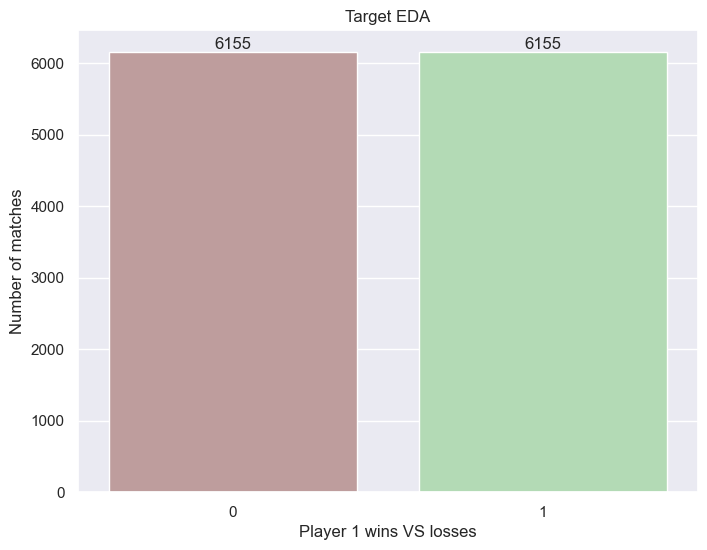

In [6]:
ax= sns.countplot(x='p1_won', data=data, palette=["#c39797", "#ace1af"])
ax.bar_label(ax.containers[0])
ax.set_title('Target EDA')
ax.set_xlabel('Player 1 wins VS losses')
ax.set_ylabel('Number of matches')
plt.show()

Conclusion : 
On est face à un problème supervisé de <b> classification binaire avec des classes équilibrées. </b> <br>
Les métriques qu'il faudrait donc utiliser pour juger la performance du modèle sont :

- Accuracy
- Precision
- Recall
- F1-score : une mesure qui permet de donner une valeur équilibrée entre la précision et le recall



### Missing values

In [7]:
def display_na(all_data):
    all_data_na = (all_data.isnull().sum() / len(all_data)) * 100
    all_data_na = all_data_na.drop(all_data_na[all_data_na == 0].index).sort_values(ascending=False)
    f, ax = plt.subplots(figsize=(8, 6))
    plt.xticks(rotation='90')
    sns.barplot(x=all_data_na.index, y=all_data_na)
    plt.xlabel('Features', fontsize=15)
    plt.ylabel('Percent of missing values', fontsize=15)
    plt.title('Percent missing data by feature', fontsize=15)

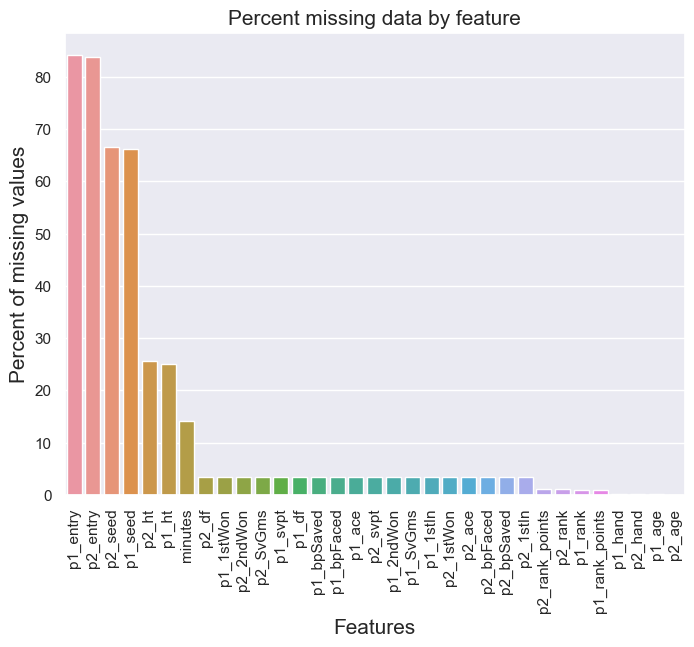

In [8]:
display_na(data)

###  Variables catégoriques

In [9]:
features = {c: data[c].nunique() for c in data.columns}
features_with_nb_categories ={k:v for k, v in sorted(features.items(), key=lambda item: item[1])} 
features_with_nb_categories

{'best_of': 2,
 'p1_won': 2,
 'p2_hand': 3,
 'p1_hand': 3,
 'surface': 5,
 'tourney_level': 5,
 'p1_entry': 6,
 'p2_entry': 7,
 'round': 9,
 'p2_ht': 19,
 'p1_ht': 19,
 'p1_df': 20,
 'p2_df': 21,
 'p1_bpSaved': 24,
 'p2_bpSaved': 25,
 'p1_bpFaced': 30,
 'p2_bpFaced': 31,
 'p2_seed': 33,
 'p1_seed': 33,
 'p2_SvGms': 40,
 'p1_SvGms': 40,
 'p2_ace': 51,
 'p1_ace': 52,
 'p2_2ndWon': 54,
 'p1_2ndWon': 54,
 'p1_ioc': 86,
 'p2_ioc': 88,
 'p2_1stWon': 110,
 'p1_1stWon': 114,
 'p2_1stIn': 142,
 'p1_1stIn': 146,
 'tourney_date': 179,
 'p1_svpt': 211,
 'p2_svpt': 213,
 'minutes': 284,
 'match_num': 343,
 'tourney_name': 374,
 'tourney_id': 579,
 'p1_id': 628,
 'p1_name': 628,
 'p2_id': 657,
 'p2_name': 657,
 'p2_rank': 683,
 'p1_rank': 716,
 'p1_age': 1914,
 'p2_age': 1928,
 'p2_rank_points': 1964,
 'p1_rank_points': 1987,
 'score': 3729}

- **Les variables catégoriques** prennent en effet des valeurs dans un ensemble finit de valeur, la question qui reste à savoir est le cardinal de cette ensemble. **Nous supposerons que la valeur limite à partir de laquelle nous considérerons la variable comme non catégorique est 10** :
        - Best_of : [3, 5]
        - pi_hand : ['L', 'R', 'U']   # U: Unkonwn
        - surface : ['Hard', 'Grass', 'Clay', 'None', 'Carpet'] # None
        - tourney_level : ['M', 'A', 'G', 'D', 'F']  # A : other tour-level events
        - pi_entry : ['Q', 'SE', 'LL', 'WC', 'PR', 'ALT', 'S']  
        - round : ['R64', 'R32', 'R16', 'QF', 'R128', 'SF', 'F', 'RR', 'BR']
        - p1_ioc : The country of origin ['FRA', 'GER', 'SUI', 'URU', 'CAN', 'USA' ...] (88 countries)
        - pi_name/pi_id : 675 players

**Winner name**

In [10]:
df_eda = data.copy()
df_eda['winner_name'] = np.where(df_eda['p1_won'] == 1, df_eda['p1_name'], df_eda['p2_name'])
df_eda[[ 'p1_name', 'p2_name', 'p1_won', 'winner_name']].head()

,p1_name,p2_name,p1_won,winner_name
0,Jo Wilfried Tsonga,Fernando Verdasco,0,Fernando Verdasco
1,Jan Lennard Struff,Marcos Baghdatis,1,Jan Lennard Struff
2,Stanislas Wawrinka,Donald Young,1,Stanislas Wawrinka
3,Pablo Cuevas,Rafael Nadal,0,Rafael Nadal
4,Frank Dancevic,Igor Sijsling,0,Igor Sijsling


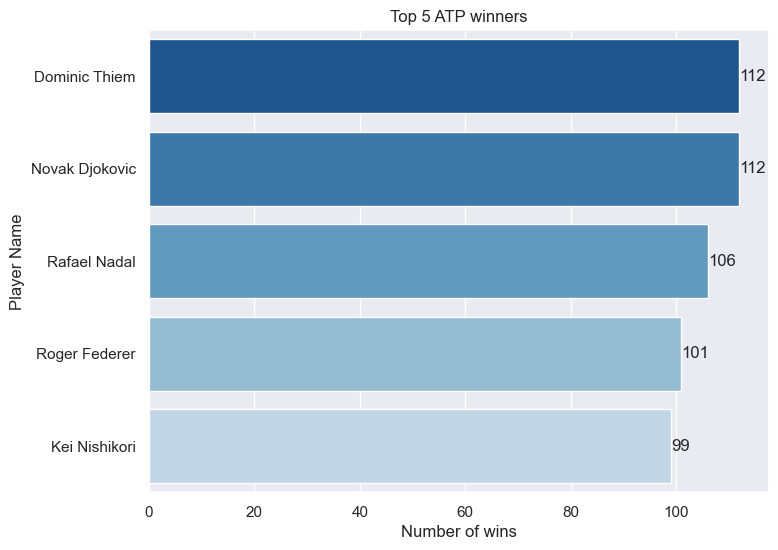

In [11]:
order = df_eda.groupby('winner_name').agg({'p1_won':'sum'})
order = order.apply(lambda x: x.sort_values(ascending=False)[:5])
order = order.reset_index()
# The three (3) ATP players with most wins
palette = sns.color_palette("Blues_r")
ax = sns.barplot(x="p1_won", y="winner_name", data=order, palette=np.array(palette)[order.index])
ax.bar_label(ax.containers[0])
ax.set_title('Top 5 ATP winners')
ax.set_ylabel('Player Name')
ax.set_xlabel('Number of wins')
plt.show()

### Date

La variable **tourney_date** est indiquée sous forme numérique alors que ce n'est pas le format adéquat pour représenter une date et qui nécessite donc un prétraitement.

In [12]:
data.tourney_date.min(), data.tourney_date.max() 

(20150104, 20190225)

<AxesSubplot:xlabel='tourney_date', ylabel='Density'>

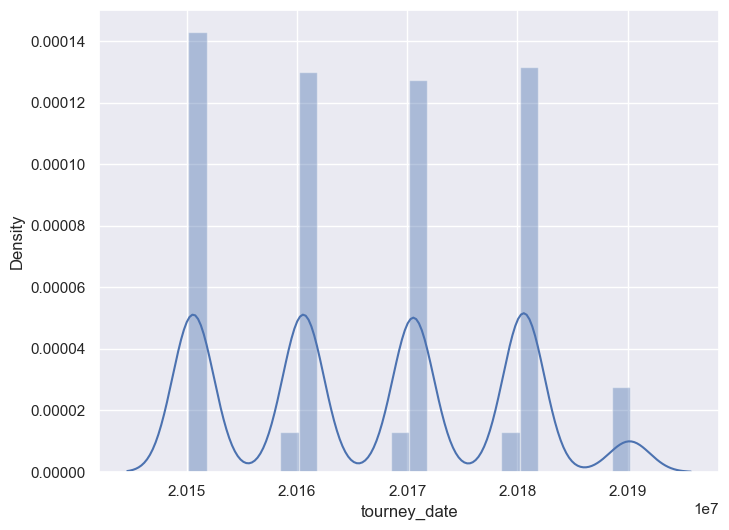

In [13]:
sns.distplot(data.tourney_date)      

--------------------------------------------------------------------------------------------

### 2.2 Variables catégoriques

#### player hand


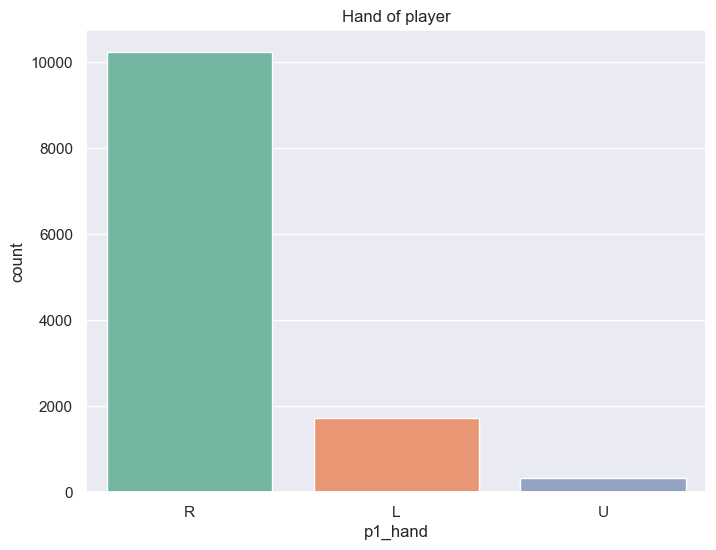

In [34]:
ax = sns.countplot(x='p1_hand', data=data, palette=sns.color_palette("Set2"))
ax.set_title("Hand of player")
plt.show()

As we can notice here, most of players use their right hand which is evident, and as we already have an extra class "U", we will use it to impute missing values

#### Tournament level


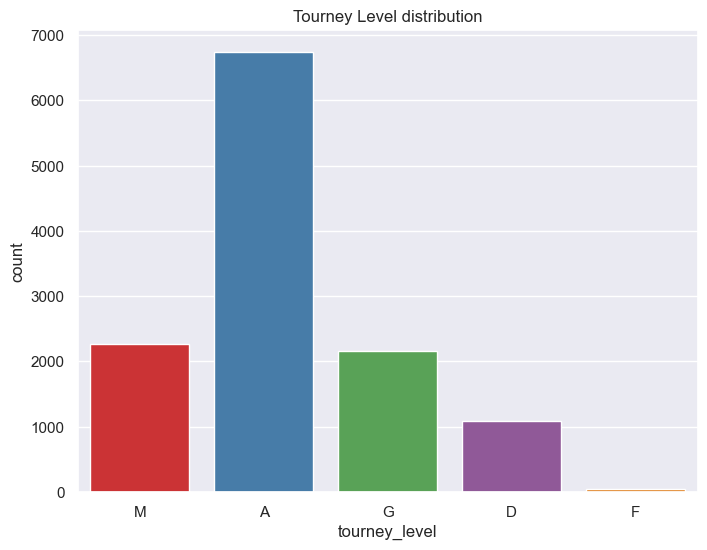

In [37]:
ax = sns.countplot(x='tourney_level', data=data, palette=sns.color_palette("Set1"))
ax.set_title("Tourney Level distribution")
plt.show()

    - 'G' = Grand Slams
    - 'M' = Masters 1000s
    - 'A' = other tour-level events
    - 'C' = Challengers
    - 'S' = Satellites/ITFs
    - 'F' = Tour finals and other season-ending events
    - 'D' = Davis Cup

As we can notice here, there are not data for S and C tournement level in our data

#### Surface Type

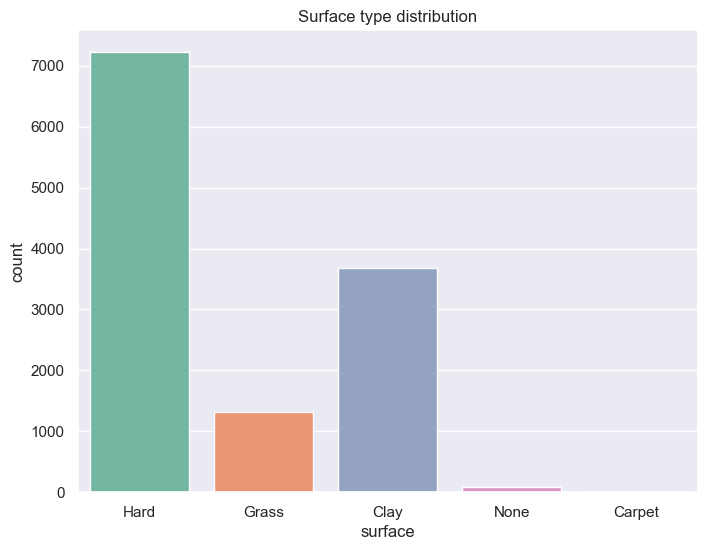

In [36]:
ax = sns.countplot(x="surface", data=data, palette=sns.color_palette("Set2"))
ax.set_title("Surface type distribution")
plt.show()

#### Height

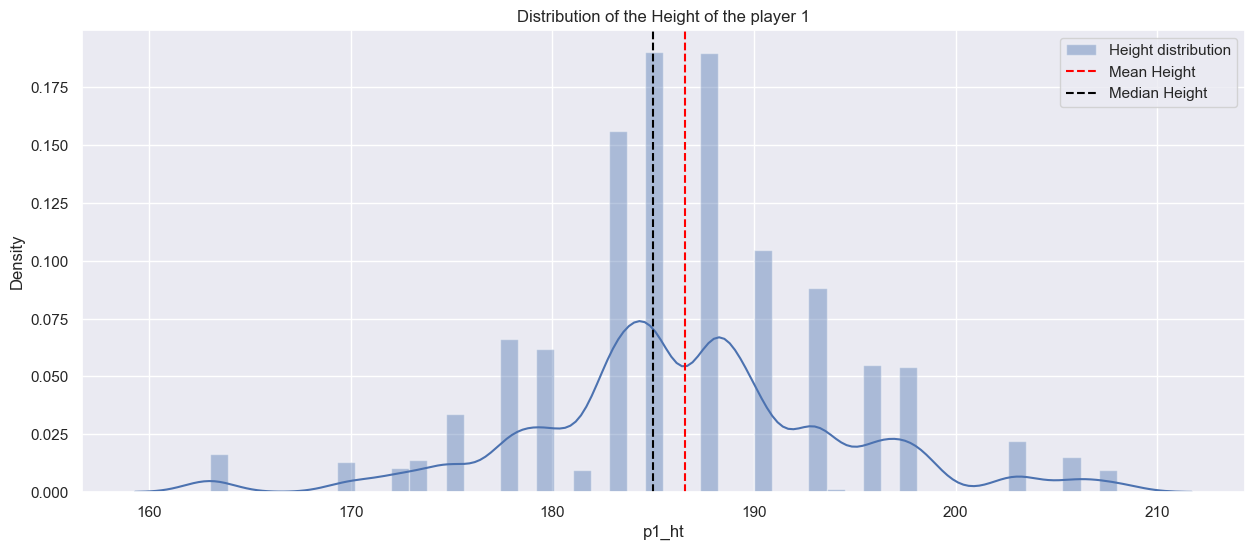

In [16]:
plt.figure(figsize=(15,6))
sns.distplot(data['p1_ht'], label='Height distribution')
plt.axvline(x=data['p1_ht'].mean(), color='red', linestyle='--', label='Mean Height')
plt.axvline(x=data['p1_ht'].median(), color='black', linestyle='--', label='Median Height')
plt.title('Distribution of the Height of the player 1')
plt.legend()
plt.show()

**score**

In [17]:
data['score'][0]

'4-6 6-3 6-4'

In [18]:
data['score'][0].split()

['4-6', '6-3', '6-4']

In [19]:
nb_sets = [len(data["score"][0].split())]
games_during_all_matchs = [g.split('-') for g in data["score"][0].split()]
games_list = []
for s in games_during_all_matchs:
    games = 0 
    for g in s :
        try:
            games += int(g[0]) + int(g[1]) 
        except:
            continue
    games_list.append(games)
print(f'nb of sets {nb_sets},\ngames during match{games_during_all_matchs}')

nb of sets [3],
games during match[['4', '6'], ['6', '3'], ['6', '4']]


--------------------------------------------------------------------------------------------------------------
<a id = 'preprocessing'></a>
### 3. Preprocessing

In [20]:
class PreProcessing:
    """Deal with nan values, drop useless columns"""
    
    def __init__(self, data: pd.DataFrame, features_to_drop:list[str], features_to_fill_by_median:list[str],\
         features_to_fill_by_new_category:list[str]) -> None:
        self.data = data.copy()
        self.features_to_drop = features_to_drop
        self.features_to_fill_by_median = features_to_fill_by_median
        self.features_to_fill_by_new_category = features_to_fill_by_new_category

    def preprocess(self) -> pd.DataFrame:
        """ Drop dupclicated, Apply missing values imputation """

        print(f'''\n{'-'*20} Preprocessing data  {'-'*20}''')
        # drop duplicates
        self.data.drop_duplicates(inplace=True)
        # drop useless cols
        print(f'Features to drop: {self.features_to_drop}')
        self.data.drop(columns=self.features_to_drop, inplace=True)
        # fill nan values
        self._fill_nan_values()
        return self.data
        

    def _get_columns_with_nan_values(self) -> dict[str, str]:
        """
        Find columns that contain nan values.
        """
        nb_rows = len(self.data)
        features_with_nan_values: dict[str, float] = {
            c: round((1 - self.data[c].count() / nb_rows) * 100, 2)
            for c in self.data.columns
            if self.data[c].count() < nb_rows
        }
        return {
            k: f'{str(v)}%'
            for k, v in sorted(
                features_with_nan_values.items(),
                key=lambda item: item[1],
                reverse=True,
            )
        }
                
 
    def _fill_nan_values(self) -> None:
        """
        Fill nan values
        """
        features_with_nan_values = self._get_columns_with_nan_values()
        print(f'\nFeatures with missing values : {json.dumps(features_with_nan_values, indent = 4)}')
        print(f'\nFeatures to fill missing values with median : {self.features_to_fill_by_median}')
        print(f'\nFeatures to fill missing values with a new category unknown : {self.features_to_fill_by_new_category}')
              
        for c in self.features_to_fill_by_median:
            self.data[c] = self.data[c].fillna((self.data[c].median()))
                        
        for c in self.features_to_fill_by_new_category:
            # fill nan values by a new category unknown(unk)
            self.data[c] = self.data[c].astype('str').replace("nan", "unk") 
        
        ## fillna for pi_hand with 'U' as there is already an unkonwn category
        self.data['p1_hand'] = self.data['p1_hand'].fillna('U')
        self.data['p2_hand'] = self.data['p2_hand'].fillna('U')
        self.data.reset_index(inplace=True, drop=True)
        
        features_with_nan_values = self._get_columns_with_nan_values()
        print(f'\nFeatures with missing values after pre-processing: {features_with_nan_values}')
            
        return None
    
   

In [21]:
params = {
'features_to_drop': ['tourney_name', 'tourney_id', 'p2_name', 'p1_name'],
    
'features_to_fill_by_median': ['p1_1stIn', 'p1_1stWon', 'p1_2ndWon', 'p1_SvGms', 'p1_ace', 'p1_bpFaced', 'p1_bpSaved',
                               'p1_df', 'p1_svpt', 'p1_rank', 'p1_rank_points', 'p1_age', 'p1_ht', 'p2_1stIn', 'p2_1stWon',
                               'p2_2ndWon', 'p2_SvGms', 'p2_ace', 'p2_bpFaced', 'p2_bpSaved', 'p2_df', 'p2_svpt', 'p2_rank',
                               'p2_rank_points', 'p2_age', 'p2_ht', 'minutes'],    
'features_to_fill_by_new_category': ['p1_seed', 'p1_entry', 'p2_seed', 'p2_entry']
}

In [22]:
# Preprocess data
preprocessing = PreProcessing(data, params['features_to_drop'],  \
    params['features_to_fill_by_median'], params['features_to_fill_by_new_category'])
preprocessing.preprocess()
print(f'\nData shape after preprocessing : {preprocessing.data.shape}')


-------------------- Preprocessing data  --------------------
Features to drop: ['tourney_name', 'tourney_id', 'p2_name', 'p1_name']

Features with missing values : {
    "p1_entry": "84.22%",
    "p2_entry": "83.7%",
    "p2_seed": "66.5%",
    "p1_seed": "66.13%",
    "p2_ht": "25.53%",
    "p1_ht": "25.09%",
    "minutes": "14.05%",
    "p2_1stIn": "3.31%",
    "p2_1stWon": "3.31%",
    "p2_2ndWon": "3.31%",
    "p2_SvGms": "3.31%",
    "p2_ace": "3.31%",
    "p2_bpFaced": "3.31%",
    "p2_bpSaved": "3.31%",
    "p2_df": "3.31%",
    "p2_svpt": "3.31%",
    "p1_1stIn": "3.31%",
    "p1_1stWon": "3.31%",
    "p1_2ndWon": "3.31%",
    "p1_SvGms": "3.31%",
    "p1_ace": "3.31%",
    "p1_bpFaced": "3.31%",
    "p1_bpSaved": "3.31%",
    "p1_df": "3.31%",
    "p1_svpt": "3.31%",
    "p2_rank": "1.14%",
    "p2_rank_points": "1.14%",
    "p1_rank": "0.87%",
    "p1_rank_points": "0.87%",
    "p2_hand": "0.19%",
    "p1_hand": "0.19%",
    "p1_age": "0.07%",
    "p2_age": "0.04%"
}

Featu

--------------------------------------------------------------------------------------------------------------
<a id = 'engineering'></a>
### 3. Feature Engineering

In [39]:
class FeatureEngineering:
    def __init__(self, data: pd.DataFrame, categorical_features: list[str], sk_kt_cols: list[str]) -> None:
        self.data = data.copy()
        self.categorical_cols = categorical_features
        self.sk_kt_cols = sk_kt_cols
        
    def _split_date(self) -> None:
        """
        Extract the year, the month and the day from the column tourney date.
        """
        
        self.data["day"] = self.data["tourney_date"]%100
        self.data["month"] = (self.data["tourney_date"]//100)%100
        self.data["year"] = self.data["tourney_date"]//10000
        datetime_feature = pd.to_datetime(self.data['tourney_date'].map(lambda x : str(x)))
        self.data['day_of_week'] = datetime_feature.apply(lambda val: val.day_name())
        self.categorical_cols.append('day_of_week')
        self.data['is_weekend'] = datetime_feature.map(lambda x : 1 if x.weekday() >= 5 else 0 )
        self.categorical_cols.append('is_weekend')
        self.data.drop(columns=["tourney_date"], inplace=True)
    
    def _importance_tourney(self) -> None:
        """
        Set A new column which represent the importance of the tourney.
        """
        importance_dict = {"G":6, "M": 5, "A": 4, "C": 4, "S": 3, "F" : 2, "D": 1}
        importance = [importance_dict[k] for k in self.data["tourney_level"].tolist()]
        self.data["tourney_importance"] = importance
        
    def _sets_per_match(self) -> None:
        """
        Get the number of set per match.
        """
        self.data["nbr_sets"] = [len(match.split()) for match in self.data["score"]]
    
    def _game_per_match(self) -> None:
        """
        Get the number of game played during a match.
        """
        games_during_all_matchs = [[g.split('-') for g in match.split()] for match in self.data["score"]]

        games_list = []
        for s in games_during_all_matchs:
            games = 0
            for g in s:
                try:
                    games += int(g[0]) + int(g[1])
                except Exception:
                    continue
            games_list.append(games)

        self.data['games_per_match'] = games_list
        self.data.drop(columns=["score"], inplace=True)
        
    def _process_categorical_data(self) -> None:
        """
        Apply get dummies for categorical data.
        """
        self.data = pd.get_dummies(self.data, columns=self.categorical_cols)
        
    def _log_transform(self) -> None:
        """
        Apply log function to normalize numerical columns that need to be transformed
        """
        for col in self.sk_kt_cols:
            try:
                self.data[f'log_{col}'] = np.log1p(self.data[col])
            except Exception:
                self.sk_kt_cols.remove(col)
        self.data.drop(columns=self.sk_kt_cols, inplace=True)
    
    def _transform_seed_as_categorical(self):
        """
        Consider seed as a categorical variable.
        """
        for p in [1, 2]:    
            self.data[f"p{p}_seed"] = self.data[f"p{p}_seed"].astype(str)
            

    @staticmethod
    def add_noise(series, noise_level):
        return series * (1 + noise_level * np.random.randn(len(series)))
    
    @staticmethod
    def target_encode(trn_series=None, 
                    tst_series=None, 
                    target=None, 
                    min_samples_leaf=1, 
                    smoothing=1,
                    noise_level=0):
        """
        Smoothing is computed like in the following paper by Daniele Micci-Barreca
        https://kaggle2.blob.core.windows.net/forum-message-attachments/225952/7441/high%20cardinality%20categoricals.pdf
        trn_series : training categorical feature as a pd.Series
        tst_series : test categorical feature as a pd.Series
        target : target data as a pd.Series
        min_samples_leaf (int) : minimum samples to take category average into account
        smoothing (int) : smoothing effect to balance categorical average vs prior  
        """ 
        assert len(trn_series) == len(target)
        assert trn_series.name == tst_series.name
        temp = pd.concat([trn_series, target], axis=1)
        
        # Compute target mean 
        averages = temp.groupby(by=trn_series.name)[target.name].agg(["mean", "count"])
        
        # Compute smoothing
        smoothing = 1 / (1 + np.exp(-(averages["count"] - min_samples_leaf) / smoothing))
        
        # Apply average function to all target data
        prior = target.mean()
        
        # The bigger the count the less full_avg is taken into account
        averages[target.name] = prior * (1 - smoothing) + averages["mean"] * smoothing
        averages.drop(["mean", "count"], axis=1, inplace=True)
        
        # Apply averages to trn and tst series
        ft_trn_series = pd.merge(
            trn_series.to_frame(trn_series.name),
            averages.reset_index().rename(columns={'index': target.name, target.name: 'average'}),
            on=trn_series.name,
            how='left')['average'].rename(trn_series.name + '_mean').fillna(prior)
        
        # pd.merge does not keep the index so restore it
        ft_trn_series.index = trn_series.index 
        ft_tst_series = pd.merge(
            tst_series.to_frame(tst_series.name),
            averages.reset_index().rename(columns={'index': target.name, target.name: 'average'}),
            on=tst_series.name,
            how='left')['average'].rename(trn_series.name + '_mean').fillna(prior)
        
        # pd.merge does not keep the index so restore it
        ft_tst_series.index = tst_series.index
        
        return FeatureEngineering.add_noise(ft_trn_series, noise_level), FeatureEngineering.add_noise(ft_tst_series, noise_level)

    def transform(self) -> pd.DataFrame:
        """
        Apply the feature engineering pipeline.
        """
        # Add date features : 
        self._split_date()
        # Add importance tourney feature:
        self._importance_tourney()
        # Add number of set per match:
        self._sets_per_match()
        # Add the number of game pet match:
        self._game_per_match()
        # Scale numerical data in order to deal with outliers problem:
        self._log_transform()
        # Transform seed column as categorical variable
        self._transform_seed_as_categorical()
        # create a dummies variables for categorical data
        self._process_categorical_data()
        return self.data

In [40]:
def apply_feature_engineering(data: pd.DataFrame, params: dict[str, str]) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series,pd.Series]:
    """ Apply feature engineering on both train and test data """

    print(f'''\n{'-'*20} Feature Engineering  {'-'*20}''')
    y = data["p1_won"]
    X = data.drop(columns=['p1_won'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    X_train.reset_index(inplace=True, drop=True)
    y_train.reset_index(inplace=True, drop=True)

    X_test.reset_index(inplace=True, drop=True)
    y_test.reset_index(inplace=True, drop=True)
    # Feature engineering
    feature_engineering_train = FeatureEngineering(X_train, params['categorical_features_dummies'], params['sk_kt_study_list'])
    X_train = feature_engineering_train.transform()

    feature_engineering_test = FeatureEngineering(X_test, params['categorical_features_dummies'], params['sk_kt_study_list'])
    X_test = feature_engineering_test.transform()
    print(f'\nX_train shape after feature engineering : {X_train.shape}')
    print(f'\nX_test shape after feature engineering : {X_test.shape}')

    X_train.drop(columns=params["redundant_features"], inplace=True)
    X_test.drop(columns=params["redundant_features"], inplace=True)

    print(f'\nX_train shape after removing redundant features : {X_train.shape}')
    print(f'\nX_test shape after removing redundant features : {X_test.shape}')
    
    return X_train, X_test, y_train, y_test

In [41]:
params.update({
'categorical_features_dummies': ['best_of', 'p2_entry', 'p2_hand', 'round', 'surface', 'tourney_level',
                                 'p1_entry', 'p1_hand', 'p1_ioc', 'p2_ioc', 'p1_seed', 'p2_seed'],
    
'sk_kt_study_list': ['p2_1stIn', 'p2_1stWon', 'p2_2ndWon', 'p2_SvGms', 'p2_ace', 'p2_bpFaced', 'p2_bpSaved', 'p2_df', 'p2_svpt', 'match_num', 'minutes', 'p1_1stIn', 'p1_1stWon', 'p1_2ndWon', 'p1_SvGms', 'p1_ace', 'p1_bpFaced', 'p1_bpSaved', 'p1_df', 'p1_svpt'],
'redundant_features': ['log_p2_1stIn', 'log_p2_1stWon', 'log_minutes', 'log_p2_SvGms', 'log_p2_svpt', 'p2_hand_L', 'best_of_3', 'best_of_5', 'p1_hand_L']
})

In [42]:
# Feature engineering
X_train, X_test, y_train, y_test = apply_feature_engineering(preprocessing.data, params)


-------------------- Feature Engineering  --------------------

X_train shape after feature engineering : (9848, 328)

X_test shape after feature engineering : (2462, 320)

X_train shape after removing redundant features : (9848, 319)

X_test shape after removing redundant features : (2462, 311)


--------------------------------------------------------------------------------------------------------------
<a id = 'train'></a>
### 4. Entrainement des modèles

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, accuracy_score, classification_report
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

def train_models(X_train, y_train) -> None:
    """ Train models """

    print(f'''\n{'-'*20} Train models and choose the best one  {'-'*20}''')
    models = {'LGBMClassifier': LGBMClassifier,
       'XGBClassifier':XGBClassifier,
    }

    best_m =''
    best_sc = 0
    for model in models:
        print(f'\nModel : {model}')
        score = score_classifier(X_train, models[model](), y_train)
        if score > best_sc:
            best_sc = score
            best_m = model
    print(f'Best model based on f1 score :{best_m} with score : {round(best_sc*100,2)} %')
    return get_best_model(X_train, y_train, models[best_m])


def score_classifier(dataset, classifier, labels):
    
    """
    Performs 3 random trainings/tests to build a confusion matrix and prints results with precision and recall scores
    Inputs :
        - dataset : the dataset to work on
        - classifier : the classifier to use
        - labels : the labels used for training and validation
    :return:
    """
    n_splits = 3
    kf = KFold(n_splits=n_splits, random_state=50, shuffle=True)
    confusion_matrices = []
    recalls = []
    precisions = []
    accuracies = []
    f1_scores = []
    
    for training_ids, test_ids in kf.split(dataset):
        
        if type(dataset) == pd.DataFrame:
            
            training_set = dataset.loc[training_ids]
            training_labels = labels.loc[training_ids]

            test_set = dataset.loc[test_ids]
            test_labels = labels.loc[test_ids]
            
        elif type(dataset) == np.ndarray: 
            
            training_set = dataset[training_ids]
            training_labels = labels[training_ids]

            test_set = dataset[test_ids]
            test_labels = labels[test_ids]
            
        
        classifier.fit(training_set, training_labels)
        
        predicted_labels = classifier.predict(test_set)
        
        confusion_matrices.append(confusion_matrix(test_labels, predicted_labels))
        recalls.append(recall_score(test_labels, predicted_labels))
        precisions.append(precision_score(test_labels, predicted_labels))
        f1_scores.append(f1_score(test_labels, predicted_labels))
        accuracies.append(accuracy_score(test_labels, predicted_labels))
    
    
    recall = np.mean(recalls) 
    precision = np.mean(precisions)
    accuracy = np.mean(accuracies)
    f1_sc = np.mean(f1_scores)
    confusion_mat = np.mean(confusion_matrices, axis=0)
    
    print(f"Recall = {recall}")
    print(f"Precision = {precision}")
    print(f"Accuracy = {accuracy}")
    print(f"f1 score = {f1_sc}")
    print(f"\nConfusion matrix : \n\n {confusion_mat}")
    print(f"\n{'-'*20}\n")
    return f1_sc

def get_best_model(X_train , y_train, classifier):
    """ Tuning des hypermaramétres"""
    clf = GridSearchCV(
            estimator=classifier(),
            param_grid={'num_leaves': (15, 30, 45),
                        'max_depth': (-1, 5, 10, 20),
                        'learning_rate': (0.05, 0.1, 0.2, 0.4),
                        'n_estimators': (25, 50, 100, 200)
                        },
            scoring='f1',
            cv=3,
            n_jobs=3,
            verbose=1,
            refit=True)

    clf.fit(X_train,y_train)
    return classifier(**clf.best_params_)

In [43]:
# Train and choose the best model
best_model = train_models(X_train, y_train)
# Save model
#pickle.dump(best_model,'model/lightGBM_model.pkl', 'wb'))


-------------------- Train models and choose the best one  --------------------

Model : LGBMClassifier
Recall = 0.907221896436544
Precision = 0.8975326281382854
Accuracy = 0.9020105791231879
f1 score = 0.9023459323599746

Confusion matrix : 

 [[1474.66666667  169.66666667]
 [ 152.         1486.33333333]]

--------------------


Model : XGBClassifier
Recall = 0.8950326638192337
Precision = 0.8952149229521492
Accuracy = 0.8953087105852919
f1 score = 0.8951009949252566

Confusion matrix : 

 [[1472.66666667  171.66666667]
 [ 172.         1466.33333333]]

--------------------

Best model based on f1 score :LGBMClassifier with score : 90.23 %
Fitting 3 folds for each of 192 candidates, totalling 576 fits


--------------------------------------------------------------------------------------------------------------
<a id = 'predict'></a>
### 5. Prédiction et analyse des résultats

In [31]:
def intersection(lst1: list[str], lst2: list[str]) -> list[str]:
        return list(set(lst1) & set(lst2))

X_tr = X_train.copy()
X_ts = X_test.copy()

# Remove duplicate columns :
X_tr = X_tr.loc[:,~X_tr.columns.duplicated()]
X_ts = X_ts.loc[:,~X_ts.columns.duplicated()]

# Get columns intersection : 
cols = intersection(list(X_tr.columns), list(X_ts.columns))

X_tr = X_tr[cols]
X_ts = X_ts[cols]

assert list(X_tr.columns) == list(X_ts.columns)

def predict(model, X_train: pd.DataFrame, X_test: pd.DataFrame, y_train: pd.Series):
    """
    input:
        - model : model after tuning hyperparameters
        - X_train : training set dataframe after feature engineering
        - y_train : ground truth of the trianing set
        - X_test : test set dataframe after feature engineering
    output : 
        
    """
    print(f'''\n{'-'*20} Model prediction  {'-'*20}''')
    
    
    model.fit(X_train, y_train)
   
    return model.predict(X_ts)

y_pred = predict(best_model, X_tr, X_ts, y_train)
print(classification_report(y_test, y_pred))



-------------------- Model prediction  --------------------
              precision    recall  f1-score   support

           0       0.91      0.92      0.91      1222
           1       0.92      0.91      0.92      1240

    accuracy                           0.91      2462
   macro avg       0.91      0.91      0.91      2462
weighted avg       0.91      0.91      0.91      2462



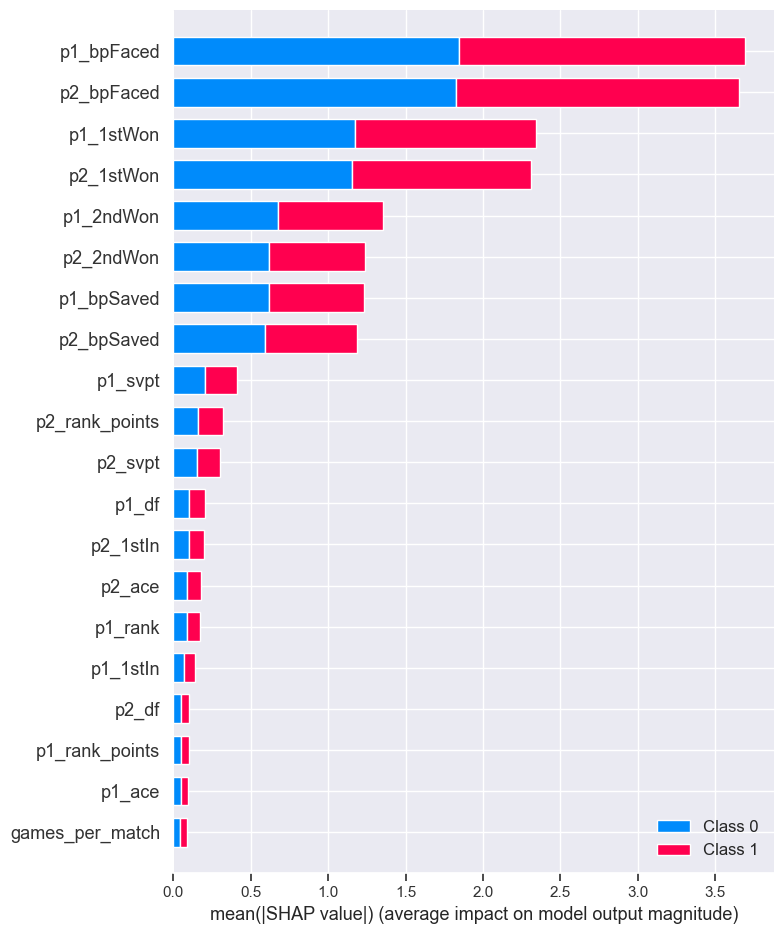

In [32]:
# explication of model results with shap values
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_ts)
shap.summary_plot(shap_values, X_ts)
